PREDICTION OF STORE SALES

In [16]:
# Preprocessing

In [17]:
# Load the Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import logging
import os
import pickle
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [22]:
!rm -rf /content/drive

In [23]:
# Load Cleaned Data
from google.colab import drive
drive.mount('/content/drive')
logger.info("Google Drive mounted.")

train = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/project6/train_cleaned.csv"
)

test = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/project6/test_cleaned.csv"
)

logger.info("Cleaned train and test data loaded")

print("Train:", train.shape)
print("Test:", test.shape)

Mounted at /content/drive
Train: (1017209, 29)
Test: (41088, 23)


In [18]:
# Logging Setup

logging.basicConfig(
    filename="rossmann_task2.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger()

logger.info("Task 2 started")

print("Logging initialized successfully")

Logging initialized successfully


In [24]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

In [25]:
# Sort the Data by Date

train = train.sort_values("Date")
test = test.sort_values("Date")

train = train.sort_values(["Store", "Date"])
test = test.sort_values(["Store", "Date"])

In [26]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'IsWeekend', 'Quarter', 'IsHoliday',
       'CompetitionDistanceBand', 'CompetitionOpenDate',
       'MonthsSinceCompetition', 'CompetitionPeriod'],
      dtype='object')

In [27]:
test.columns

Index(['Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month',
       'Day', 'WeekOfYear', 'IsWeekend', 'Quarter', 'IsHoliday'],
      dtype='object')

In [28]:
# Create Date features

train["Date_DayOfWeek"] = train["Date"].dt.dayofweek
test["Date_DayOfWeek"] = test["Date"].dt.dayofweek

In [29]:
train["IsWeekend"] = (
    train["Date"].dt.dayofweek >= 5
).astype(int)

test["IsWeekend"] = (
    test["Date"].dt.dayofweek >= 5
).astype(int)

In [30]:
def month_period(day):

    if day <= 10:
        return "Beginning"

    elif day <= 20:
        return "Middle"

    else:
        return "End"

In [31]:
train["MonthPeriod"] = train["Date"].dt.day.apply(month_period)
test["MonthPeriod"] = test["Date"].dt.day.apply(month_period)

In [32]:
# Month start/End

train["IsMonthStart"] = (
    train["Date"].dt.is_month_start
).astype(int)

train["IsMonthEnd"] = (
    train["Date"].dt.is_month_end
).astype(int)

test["IsMonthStart"] = (
    test["Date"].dt.is_month_start
).astype(int)

test["IsMonthEnd"] = (
    test["Date"].dt.is_month_end
).astype(int)

In [33]:
# Year ,month,day

for df in [train, test]:

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["Date"].dt.quarter

In [34]:
# Holiday Features

train["IsStateHoliday"] = (
    train["StateHoliday"] != "0"
).astype(int)

test["IsStateHoliday"] = (
    test["StateHoliday"] != "0"
).astype(int)

train["IsSchoolHoliday"] = train["SchoolHoliday"]

test["IsSchoolHoliday"] = test["SchoolHoliday"]

In [35]:
# Days to / After Holiday

holiday_dates = train.loc[
    train["IsStateHoliday"] == 1,
    "Date"
].drop_duplicates().sort_values().values

def holiday_distance(date, holiday_dates):

    if len(holiday_dates) == 0:
        return 999, 999

    distances = np.array([
        (pd.Timestamp(h) - date).days
        for h in holiday_dates
    ])

    future = distances[distances >= 0]
    past = distances[distances < 0]

    days_to_holiday = (
        future.min() if len(future) > 0 else 999
    )

    days_after_holiday = (
        abs(past.max()) if len(past) > 0 else 999
    )

    return days_to_holiday, days_after_holiday

In [36]:
train[
    ["DaysToHoliday", "DaysAfterHoliday"]
] = train["Date"].apply(
    lambda x: pd.Series(
        holiday_distance(x, holiday_dates)
    )
)

In [37]:
test[
    ["DaysToHoliday", "DaysAfterHoliday"]
] = test["Date"].apply(
    lambda x: pd.Series(
        holiday_distance(x, holiday_dates)
    )
)

In [38]:
# Additional Feature: Competition Age

def create_competition_date(df):

    return pd.to_datetime(
        dict(
            year=df["CompetitionOpenSinceYear"].replace(0, np.nan),
            month=df["CompetitionOpenSinceMonth"].replace(0, np.nan),
            day=1
        ),
        errors="coerce"
    )

train["CompetitionOpenDate"] = create_competition_date(train)
test["CompetitionOpenDate"] = create_competition_date(test)

In [39]:
train["CompetitionAgeMonths"] = (
    (train["Date"].dt.year -
     train["CompetitionOpenDate"].dt.year) * 12
    +
    (train["Date"].dt.month -
     train["CompetitionOpenDate"].dt.month)
)

test["CompetitionAgeMonths"] = (
    (test["Date"].dt.year -
     test["CompetitionOpenDate"].dt.year) * 12
    +
    (test["Date"].dt.month -
     test["CompetitionOpenDate"].dt.month)
)

In [40]:
train["CompetitionAgeMonths"] = (
    train["CompetitionAgeMonths"].fillna(0)
)

test["CompetitionAgeMonths"] = (
    test["CompetitionAgeMonths"].fillna(0)
)

In [41]:
# Remove Date Columns

train.drop(
    ["Date", "CompetitionOpenDate"],
    axis=1,
    inplace=True,
    errors="ignore"
)

test.drop(
    ["Date", "CompetitionOpenDate"],
    axis=1,
    inplace=True,
    errors="ignore"
)

In [42]:
# Separate X and y - target sales

X = train.drop("Sales", axis=1)
y = train["Sales"]

X_test = test.copy()

In [43]:
train_test_split(X, y, random_state=42)

[        Store  DayOfWeek  Customers  Open  Promo StateHoliday  SchoolHoliday  \
 91675     246          7          0     0      0            0              0   
 783849    790          1        806     1      1            0              1   
 63080     641          5        715     1      1            0              0   
 333323    768          5       1279     1      1            0              0   
 972209    715          7          0     0      0            0              0   
 ...       ...        ...        ...   ...    ...          ...            ...   
 708640    286          5        496     1      0            0              0   
 329282    401          2        716     1      0            0              0   
 670590    146          4        628     1      1            0              0   
 110006    737          5        739     1      0            0              0   
 244906    134          1        675     1      0            0              1   
 
        StoreType Assortme

In [44]:
split_date = pd.Timestamp("2015-06-01")

train_data = train[(train["Year"] < split_date.year) | ((train["Year"] == split_date.year) & (train["Month"] < split_date.month))]
validation_data = train[(train["Year"] > split_date.year) | ((train["Year"] == split_date.year) & (train["Month"] >= split_date.month))]

In [45]:
train = train.sort_values(["Year", "Month", "Day", "Store"])

split_index = int(len(train) * 0.8)

train_part = train.iloc[:split_index]
valid_part = train.iloc[split_index:]

In [46]:
X_train = train_part.drop("Sales", axis=1)
y_train = train_part["Sales"]

X_valid = valid_part.drop("Sales", axis=1)
y_valid = valid_part["Sales"]

Building Models with sklearn Pipelines

In [47]:
# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'WeekOfYear', 'IsWeekend', 'IsHoliday', 'MonthsSinceCompetition', 'IsMonthStart', 'IsMonthEnd', 'IsStateHoliday', 'IsSchoolHoliday', 'DaysToHoliday', 'DaysAfterHoliday', 'CompetitionAgeMonths']
Categorical: ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'CompetitionDistanceBand', 'CompetitionPeriod', 'MonthPeriod']


In [48]:
# Create preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [49]:
# Categorical pipeline:

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

Random Forest Pipeline

In [51]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [52]:
logger.info("Training Random Forest model")

# Ensure all categorical features are strings before fitting
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)

rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Store', 'DayOfWeek',
                                                   'Customers', 'Open', 'Promo',
                                                   'SchoolHoliday',
                                                   'CompetitionDistance',
                                                   'CompetitionOpenSinceMonth',
                                                   'CompetitionOpenSinceYear',
                                                   'Promo2', 'Promo2SinceWeek',
                                                   'Promo2SinceYear',
                                                   'W...
                                                   'CompetitionAgeMonths']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['StateHoliday', 'StoreType',
                                                   'Assortment',
                                                   'PromoInterval',
                                                   'CompetitionDistanceBand',
                                                   'CompetitionPeriod',
                                                   'MonthPeriod'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [53]:
# Make Predictions
rf_predictions = rf_pipeline.predict(
    X_valid
)

In [54]:
# Evaluate Model
mae = mean_absolute_error(
    y_valid,
    rf_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_predictions
    )
)

r2 = r2_score(
    y_valid,
    rf_predictions
)

print("Random Forest")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Random Forest
MAE : 353.60124918938584
RMSE: 574.0332460770749
R2  : 0.9779358477449597


In [55]:
# Choose a loss function
# MAE as the primary business metric.
# MAE was selected as the primary evaluation metric because it is directly interpretable in the original sales units and treats each prediction
#error proportionally. RMSE is additionally reported because large forecasting errors can have significant business consequences.

In [57]:
# Compare multiple models

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=5,
                random_state=42
            )
        )
    ]
)

# train
logger.info("Training Gradient Boosting model")

gb_pipeline.fit(
    X_train,
    y_train
)

#Predict
gb_predictions = gb_pipeline.predict(
    X_valid
)

#Evaluate
gb_mae = mean_absolute_error(
    y_valid,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_valid,
    gb_predictions
)

In [58]:
# Model Comparison Table

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae,
        gb_mae
    ],

    "RMSE": [
        rmse,
        gb_rmse
    ],

    "R2": [
        r2,
        gb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Random Forest,353.601249,574.033246,0.977936
1,Gradient Boosting,603.918868,897.639133,0.946047


Post Prediction Analysis

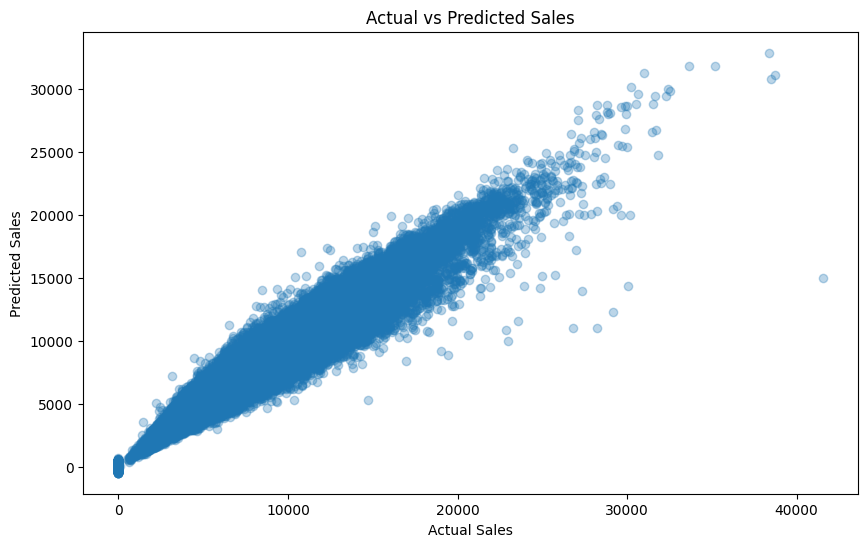

In [59]:
# Actual vs Predicted

plt.figure(figsize=(10,6))

plt.scatter(
    y_valid,
    gb_predictions,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

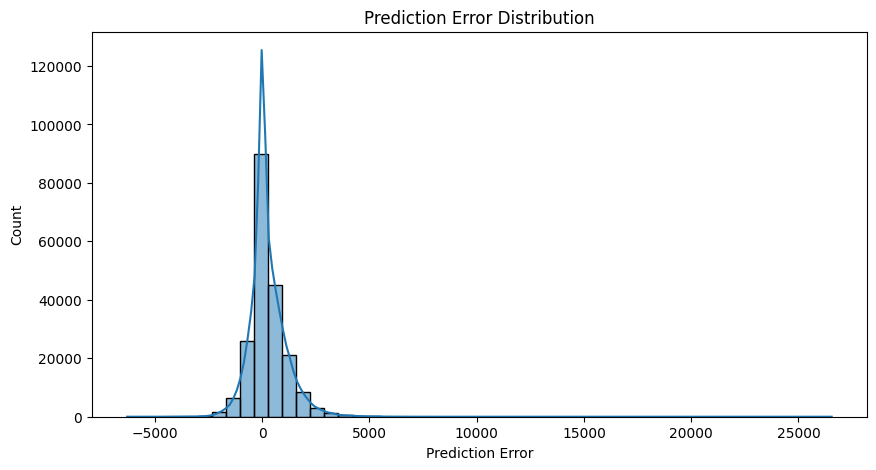

In [60]:
# Prediction Error

errors = y_valid - gb_predictions

plt.figure(figsize=(10,5))

sns.histplot(
    errors,
    bins=50,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")

plt.show()

In [61]:
# Feature Importance

model = gb_pipeline.named_steps["model"]
preprocessor_fitted = (
    gb_pipeline.named_steps["preprocessor"]
)

In [62]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [63]:
importance = model.feature_importances_

In [64]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
2,num__Customers,0.894506
30,cat__StoreType_d,0.021867
4,num__Promo,0.018952
6,num__CompetitionDistance,0.017957
32,cat__Assortment_b,0.009422
28,cat__StoreType_b,0.006536
12,num__WeekOfYear,0.005117
1,num__DayOfWeek,0.005039
0,num__Store,0.005019
10,num__Promo2SinceWeek,0.003819


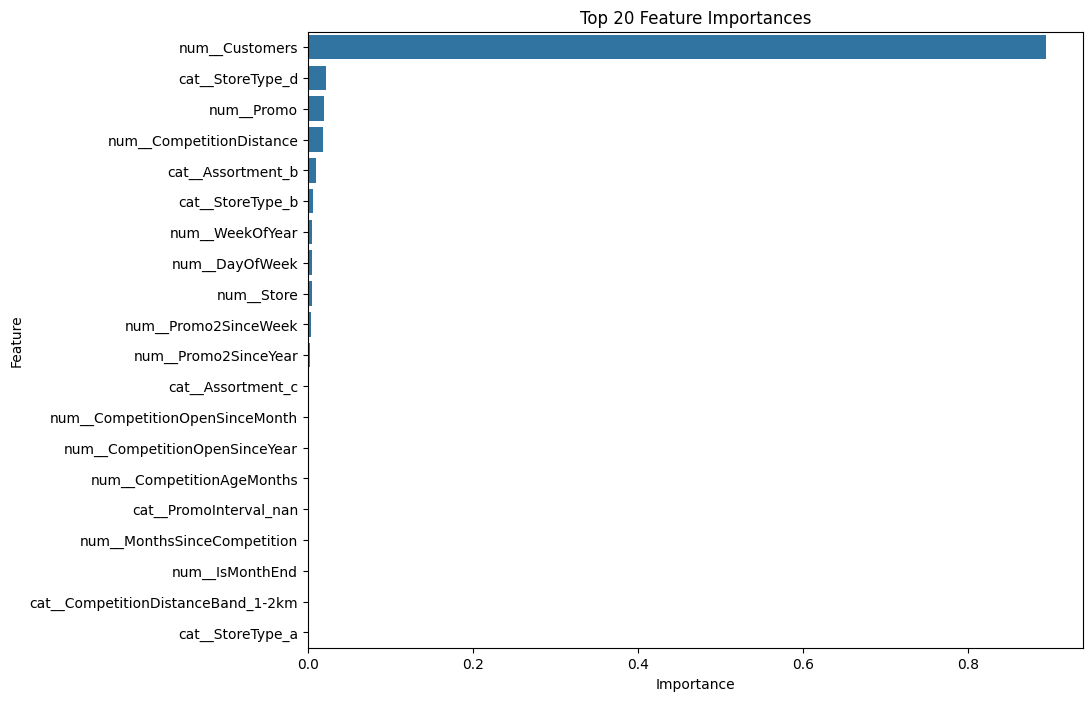

In [65]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances")

plt.show()

In [66]:
# Confidence Interval

#Creatively deduce a way to estimate the confidence interval of predictions.

residuals = y_valid - gb_predictions

lower_residual = residuals.quantile(0.025)
upper_residual = residuals.quantile(0.975)

prediction_lower = (
    gb_predictions + lower_residual
)

prediction_upper = (
    gb_predictions + upper_residual
)

In [67]:
prediction_results = pd.DataFrame({
    "Actual": y_valid.values,
    "Prediction": gb_predictions,
    "Lower_Bound": prediction_lower,
    "Upper_Bound": prediction_upper
})

prediction_results.head(20)

,Actual,Prediction,Lower_Bound,Upper_Bound
0,9572,7447.112695,6205.560618,9711.126460
1,8170,6809.165226,5567.613149,9073.178991
2,6907,6015.927642,4774.375565,8279.941407
3,4478,4547.316053,3305.763975,6811.329817
4,11872,10338.918852,9097.366774,12602.932616
5,5556,4997.131329,3755.579252,7261.145094
6,4383,4568.877404,3327.325326,6832.891169
7,5335,5053.799101,3812.247024,7317.812866
8,9028,6474.530594,5232.978517,8738.544359
9,7877,7719.436089,6477.884011,9983.449853


In [68]:
# Prediction uncertainty was estimated using the empirical distribution of validation residuals.
#The 2.5th and 97.5th residual percentiles were added to each prediction to create an approximate 95% prediction interval.

Serialize Model

In [69]:
timestamp = datetime.now().strftime(
    "%d-%m-%Y-%H-%M-%S-%f"
)

model_filename = (
    f"rossmann_model_{timestamp}.pkl"
)

with open(model_filename, "wb") as file:

    pickle.dump(
        gb_pipeline,
        file
    )

print(
    "Model saved as:",
    model_filename
)

logger.info(
    f"Model serialized: {model_filename}"
)

model_path = (
    "/content/drive/MyDrive/Colab Notebooks/project6/"
    + model_filename
)

Model saved as: rossmann_model_14-09-2026-17-09-49-953977.pkl


In [70]:
os.makedirs(
    "/content/drive/MyDrive/Colab Notebooks/project6/",
    exist_ok=True
)

In [71]:
with open(model_path, "wb") as file:
    pickle.dump(
        gb_pipeline,
        file
    )

Deep Learning — LSTM

In [72]:
daily_sales = (
    train
    .groupby(["Year", "Month", "Day"])["Sales"]
    .sum()
    .reset_index()
)

In [73]:
daily_sales = daily_sales.sort_values(["Year", "Month", "Day"])

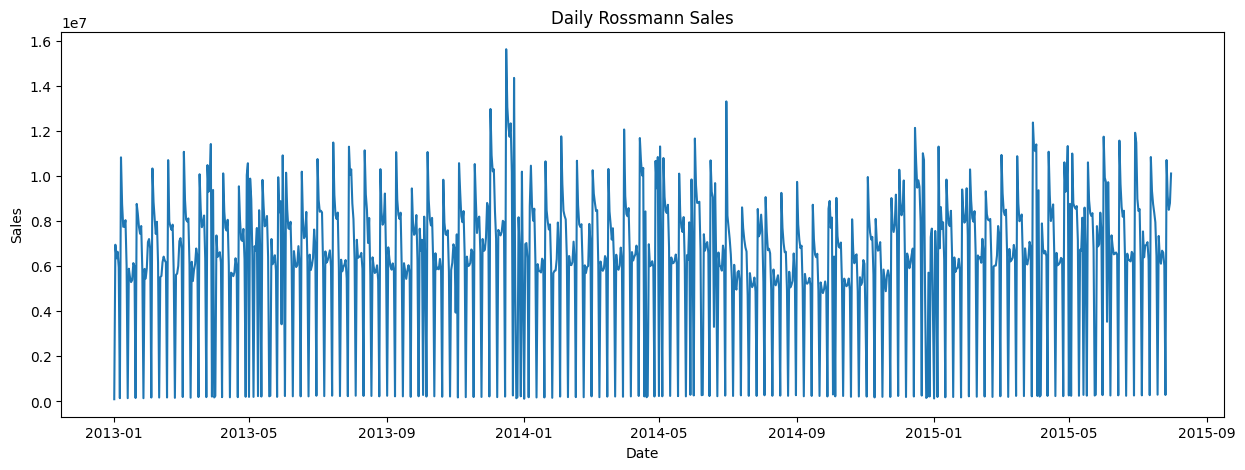

In [74]:
daily_sales["Date"] = pd.to_datetime(daily_sales[["Year", "Month", "Day"]])
daily_sales.set_index(
    "Date",
    inplace=True
)

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Sales"]
)

plt.title("Daily Rossmann Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [76]:
#Check Stationarity

In [75]:
from statsmodels.tsa.stattools import adfuller

In [77]:
result = adfuller(
    daily_sales["Sales"]
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.761614524595615
p-value: 6.436731330559343e-05


In [78]:
daily_sales["Sales_diff"] = (
    daily_sales["Sales"].diff()
)

In [79]:
daily_sales_diff = (
    daily_sales["Sales_diff"]
    .dropna()
)

In [80]:
result = adfuller(
    daily_sales_diff
)

print("p-value:", result[1])

p-value: 3.7500440046048496e-26


In [81]:
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

<Figure size 1000x500 with 0 Axes>

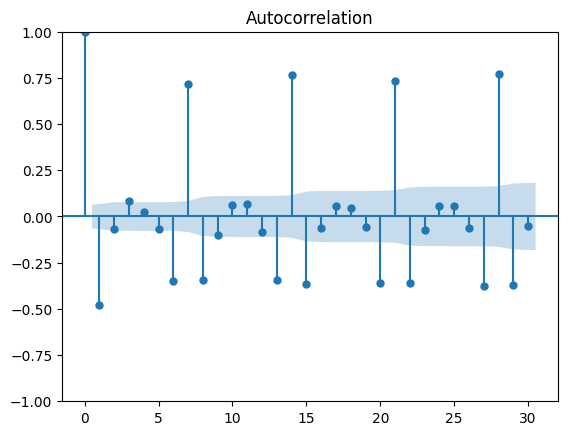

In [82]:
#ACF
plt.figure(figsize=(10,5))

plot_acf(
    daily_sales_diff,
    lags=30
)

plt.show()

<Figure size 1000x500 with 0 Axes>

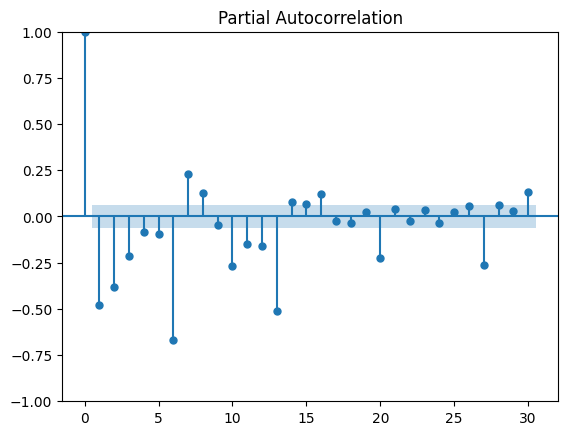

In [83]:
#PACF
plt.figure(figsize=(10,5))

plot_pacf(
    daily_sales_diff,
    lags=30
)

plt.show()

In [84]:
# Create Sliding Window

#For LSTM, convert the time series into supervised learning format.

def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(
        len(data) - window_size
    ):

        X.append(
            data[i:i + window_size]
        )

        y.append(
            data[i + window_size]
        )

    return np.array(X), np.array(y)

In [85]:
# MinMaxScaler:

from sklearn.preprocessing import MinMaxScaler

scaler_lstm = MinMaxScaler(
    feature_range=(-1, 1)
)

sales_values = (
    daily_sales["Sales"]
    .values
    .reshape(-1, 1)
)

split = int(
    len(sales_values) * 0.8
)

train_values = sales_values[:split]
test_values = sales_values[split:]

train_scaled = scaler_lstm.fit_transform(
    train_values
)

test_scaled = scaler_lstm.transform(
    test_values
)

In [86]:
# Create LSTM sequences

window_size = 14

X_lstm_train, y_lstm_train = (
    create_sequences(
        train_scaled.flatten(),
        window_size
    )
)

X_lstm_test, y_lstm_test = (
    create_sequences(
        test_scaled.flatten(),
        window_size
    )
)

In [87]:
X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

In [88]:
# Build 2-Layer LSTM using tensor flow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [89]:
lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            window_size,
            1
        )
    ),

    Dropout(0.2),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(1)
])

In [90]:
lstm_model.compile(
    optimizer="adam",
    loss="mae"
)

# train LTSTM model

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,

    epochs=20,
    batch_size=32,

    validation_split=0.1,

    verbose=1
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.2935 - val_loss: 0.3125
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2847 - val_loss: 0.3086
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2800 - val_loss: 0.3062
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2749 - val_loss: 0.3146
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2534 - val_loss: 0.3172
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2393 - val_loss: 0.3542
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2403 - val_loss: 0.3150
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2335 - val_loss: 0.3227
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2296 - val_loss: 0.3471
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.2256 - val_loss: 0.3233
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2240 - val_loss: 0.3254
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2

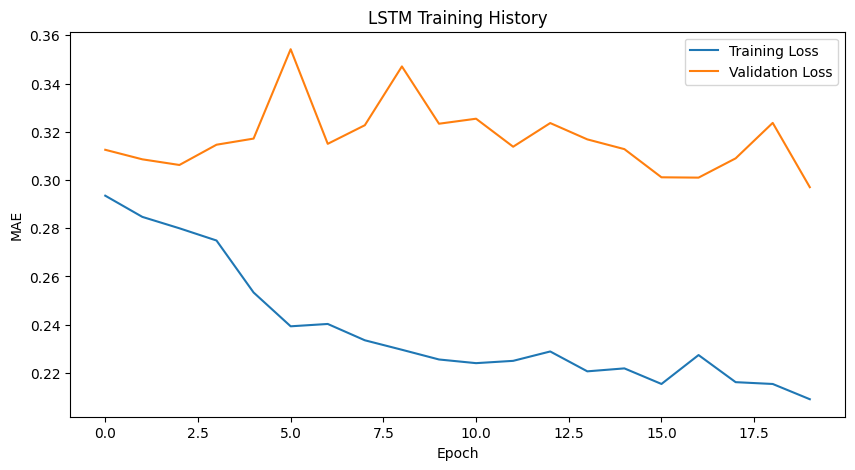

In [91]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()
plt.show()

In [92]:
# LSTM Prediction

lstm_pred_scaled = (
    lstm_model.predict(
        X_lstm_test
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [93]:
# Convert back to actual
lstm_pred_scaled = (
    lstm_model.predict(
        X_lstm_test
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [94]:
# Actual
lstm_actual = scaler_lstm.inverse_transform(
    y_lstm_test.reshape(-1, 1)
)

In [95]:
# Evaluate LSTM
lstm_pred = scaler_lstm.inverse_transform(lstm_pred_scaled)

lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    lstm_actual,
    lstm_pred
)

print("LSTM")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2  :", lstm_r2)

LSTM
MAE : 1725982.87578125
RMSE: 2583624.379769903
R2  : 0.3642341384211908


In [96]:
# Compare with ML

final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "LSTM"
    ],

    "MAE": [
        mae,
        gb_mae,
        lstm_mae
    ],

    "RMSE": [
        rmse,
        gb_rmse,
        lstm_rmse
    ],

    "R2": [
        r2,
        gb_r2,
        lstm_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R2
0,Random Forest,3.536012e+02,5.740332e+02,0.977936
1,Gradient Boosting,6.039189e+02,8.976391e+02,0.946047
2,LSTM,1.725983e+06,2.583624e+06,0.364234


ML Flow

In [97]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 695.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [98]:
import mlflow
import mlflow.sklearn

In [99]:
mlflow.set_experiment(
    "Rossmann_Sales_Prediction"
)

2026/09/14 17:13:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/14 17:13:19 INFO mlflow.store.db.utils: Updating database tables
2026/09/14 17:13:22 INFO mlflow.tracking.fluent: Experiment with name 'Rossmann_Sales_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1789406002143, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789406002143, lifecycle_stage='active', name='Rossmann_Sales_Prediction', tags={}, trace_location=None, workspace='default'>

In [100]:
# Log Random Forest / Gradient Boosting
with mlflow.start_run(
    run_name="Gradient_Boosting"
):

    mlflow.log_param(
        "model",
        "GradientBoostingRegressor"
    )

    mlflow.log_param(
        "n_estimators",
        200
    )

    mlflow.log_param(
        "learning_rate",
        0.05
    )

    mlflow.log_metric(
        "MAE",
        gb_mae
    )

    mlflow.log_metric(
        "RMSE",
        gb_rmse
    )

    mlflow.log_metric(
        "R2",
        gb_r2
    )

    mlflow.sklearn.log_model(
        gb_pipeline,
        name="rossmann_model",
        skops_trusted_types=['numpy.dtype', 'sklearn.compose._column_transformer._RemainderColsList']
    )

In [101]:
# MLflow Inference on Test Data

# Ensure the test DataFrame has the same columns as X_train
missing_cols = set(X_train.columns) - set(test.columns)
for col in missing_cols:
    test[col] = np.nan

# Reorder test columns to match X_train columns
test = test[X_train.columns]

test_predictions = gb_pipeline.predict(
    test
)

In [102]:
# Create submission

submission = pd.DataFrame({
    "Id": test.index,
    "Sales": test_predictions
})

In [103]:
test_ids = test.index.copy()

In [104]:
import os

submission.to_csv(
    "rossmann_predictions.csv",
    index=False
)

print(f"'rossmann_predictions.csv' saved to: {os.getcwd()}")

# Define the destination path in Google Drive
drive_path = "/content/drive/MyDrive/Colab Notebooks/project6/rossmann_predictions.csv"

# Copy the file to Google Drive
import shutil
shutil.copy(
    "rossmann_predictions.csv",
    drive_path
)

print(f"'rossmann_predictions.csv' copied to: {drive_path}")

'rossmann_predictions.csv' saved to: /content
'rossmann_predictions.csv' copied to: /content/drive/MyDrive/Colab Notebooks/project6/rossmann_predictions.csv


# Conclusion
## Conclusion

The objective of Task was to develop a machine-learning and deep-learning solution for predicting daily sales across Rossmann stores. The data was preprocessed by handling missing values, converting categorical variables, and creating meaningful date-based features such as day of week, weekend indicators, month, quarter, week of year, month period, holiday indicators, and competition-related features.

Multiple regression models were developed using Scikit-learn pipelines, with Random Forest and Gradient Boosting used as the primary tree-based algorithms. Model performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². MAE was selected as the primary metric because it provides an intuitive measure of the average prediction error in sales units, while RMSE and R² were used as supporting metrics.

Feature-importance analysis helped identify the variables that contributed most strongly to sales predictions. Features such as store characteristics, promotional activity, customer numbers, day of week, and time-related variables provided useful information for understanding sales behaviour.

A separate time-series approach was also implemented using a two-layer LSTM network. The daily sales series was analyzed for stationarity, autocorrelation, and partial autocorrelation before being transformed into supervised learning sequences. The data was scaled to the range (-1, 1), and a sliding-window approach was used to predict future sales.

The trained machine-learning model was serialized using timestamp-based `.pkl` files so that different model versions can be tracked and reused for future predictions. MLflow was also incorporated to record model parameters, evaluation metrics, and model artifacts, making the overall workflow more reproducible and suitable for deployment.

Overall, this is established a complete sales-prediction pipeline from preprocessing and feature engineering to model training, evaluation, forecasting, serialization, and experiment tracking. The resulting model can be integrated into Task 3, where store managers will be able to upload input data through a web interface and receive predicted sales and customer numbers.


In [105]:
gb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Store', 'DayOfWeek',
                                                   'Customers', 'Open', 'Promo',
                                                   'SchoolHoliday',
                                                   'CompetitionDistance',
                                                   'CompetitionOpenSinceMonth',
                                                   'CompetitionOpenSinceYear',
                                                   'Promo2', 'Promo2SinceWeek',
                                                   'Promo2SinceYear',
                                                   'W...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['StateHoliday', 'StoreType',
                                                   'Assortment',
                                                   'PromoInterval',
                                                   'CompetitionDistanceBand',
                                                   'CompetitionPeriod',
                                                   'MonthPeriod'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=5,
                                           n_estimators=200,
                                           random_state=42))])

In [108]:
import pickle
import os

# Define the directory to save the model
model_dir = "/content/drive/MyDrive/Colab Notebooks/project6/deployment/models"
os.makedirs(model_dir, exist_ok=True)

# Define the full path for the model file
model_filename = os.path.join(model_dir, "sales_model_gb.pkl")

with open(model_filename, "wb") as file:
    pickle.dump(
        gb_pipeline,
        file
    )

print(f"Sales model saved successfully to {model_filename}")

Sales model saved successfully to /content/drive/MyDrive/Colab Notebooks/project6/deployment/models/sales_model_gb.pkl


In [109]:
# Prepare data for Customer model
y_customers_train = train_part["Customers"]
y_customers_valid = valid_part["Customers"]

# Create a new pipeline for customer prediction (using Gradient Boosting as it performed well for sales)
customer_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=5,
                random_state=42
            )
        )
    ]
)

# Train the customer model
logger.info("Training Customer Gradient Boosting model")
customer_gb_pipeline.fit(
    X_train,
    y_customers_train
)

# Predict customers on validation set
customer_gb_predictions = customer_gb_pipeline.predict(
    X_valid
)

# Evaluate Customer Model
customer_gb_mae = mean_absolute_error(
    y_customers_valid,
    customer_gb_predictions
)
customer_gb_rmse = np.sqrt(
    mean_squared_error(
        y_customers_valid,
        customer_gb_predictions
    )
)
customer_gb_r2 = r2_score(
    y_customers_valid,
    customer_gb_predictions
)

print("Customer Gradient Boosting Model Evaluation:")
print(f"MAE: {customer_gb_mae:.2f}")
print(f"RMSE: {customer_gb_rmse:.2f}")
print(f"R2: {customer_gb_r2:.2f}")
logger.info(
    f"Customer Model MAE: {customer_gb_mae:.2f}, RMSE: {customer_gb_rmse:.2f}, R2: {customer_gb_r2:.2f}"
)

# Save the customer model
model_dir = "/content/drive/MyDrive/Colab Notebooks/project6/deployment/models"
os.makedirs(model_dir, exist_ok=True)

customer_model_filename = os.path.join(model_dir, "customer_model_gb.pkl")

with open(customer_model_filename, "wb") as file:
    pickle.dump(
        customer_gb_pipeline,
        file
    )

print(f"Customer model saved successfully to {customer_model_filename}")
logger.info(f"Customer model serialized: {customer_model_filename}")

Customer Gradient Boosting Model Evaluation:
MAE: 0.32
RMSE: 0.64
R2: 1.00
Customer model saved successfully to /content/drive/MyDrive/Colab Notebooks/project6/deployment/models/customer_model_gb.pkl
